# Task 2: Independent Evaluation Against an External SigLIP Model

This notebook compares the model selected in Notebook 05 with an external SigLIP season classifier on a separate labelled dataset, not on the Task 2 validation split used for model development. The evaluation data come from the RISE Clothing Dataset for Second-Hand Fashion and contain 500 images: 125 per season. The builder uses the same 12 article types with identical per-type counts in Fall, Spring, Summer, and Winter, preventing season performance from being confounded by a different product-type mix. Both models predict from the same source files, enabling paired comparison under distribution shift. Final test prediction remains the exclusive responsibility of Notebook 07.

This design provides stronger evidence of four-season transfer beyond the local training/validation sample. The balanced external labels make macro-F1 and balanced accuracy directly interpretable across every Task 2 class. The Hugging Face model is treated as an external SOTA candidate rather than verified state of the art: its documented training provenance is insufficient to rule out overlap with the external source dataset.

## How to Run

Run Notebooks 01–05 first so that the fixed winner and its complete preprocessing contract are available. Ensure that `ExtraSeasonData/ExtraSeasonData/extraSeasonData.csv` and `extraSeasonImages/` are present, install the locked dependencies with `uv sync`, and then run Sections 1–4 in order. The first execution downloads the pinned external checkpoint to the Hugging Face cache; later executions reuse that revision.

Notebook 06 does not revisit model selection or use Notebook 01's validation images. The selected model is fixed before this external evaluation, avoiding retrospective selection on the external evidence. Run Notebook 07 afterwards to generate final test predictions from that selected model only.

## Required Structure to Run

```text
Machine-Learning-Assignment-2/
├── pyproject.toml
├── src/
│   ├── preprocessing.py
│   └── task2_utils.py
├── ExtraSeasonData/ExtraSeasonData/
│   ├── extraSeasonData.csv
│   └── extraSeasonImages/
│       ├── 100000.jpg
│       └── ...
├── preprocessed_datasets/task2/
│   └── task2_metadata.json
└── models/task2/
    └── task2_model.pt  OR  task2_model.joblib
```

The CSV must provide unique `id`, `season`, and `articleType` fields, with one `<id>.jpg` file per row. Every retained article type must have the same count in each season; the setup cell validates this matched design before inference. `task2_metadata.json` is used only to verify the selected package's class order and run fingerprint; no cached training or validation arrays are loaded. Exactly one selected-model package should exist. Internet access is required only for the first download of the pinned Hugging Face revision. Results are written under `outputs/task2/independent_evaluation/`.

## 1. External evaluation setup

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModelForImageClassification

REPO_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / 'pyproject.toml').exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError('Could not find the repository root containing pyproject.toml')
sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import load_image_array
from src.task2_utils import (
    TASK2_METADATA_PATH, TASK2_MODEL_DIR, TASK2_OUTPUT_DIR, NeuralTrainer,
    build_task2_neural_model, ensure_task2_directories,
    evaluate_predictions, extract_visual_features, per_class_table,
)

ensure_task2_directories()
metadata = json.loads(TASK2_METADATA_PATH.read_text(encoding='utf-8'))
CLASSES = list(metadata['classes'])
TARGET = str(metadata.get('target', 'season'))
RUN_FINGERPRINT = str(metadata['fingerprint'])

EXTRA_DATA_DIR = REPO_ROOT / 'ExtraSeasonData' / 'ExtraSeasonData'
EXTRA_CSV_PATH = EXTRA_DATA_DIR / 'extraSeasonData.csv'
EXTRA_IMAGE_DIR = EXTRA_DATA_DIR / 'extraSeasonImages'
EVALUATION_DIR = TASK2_OUTPUT_DIR / 'independent_evaluation'
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

external_frame = pd.read_csv(EXTRA_CSV_PATH)
required_columns = {'id', 'season', 'articleType'}
missing_columns = sorted(required_columns.difference(external_frame.columns))
if missing_columns:
    raise ValueError(f'External CSV is missing required columns: {missing_columns}')
if external_frame['id'].isna().any() or external_frame['id'].duplicated().any():
    raise ValueError('External IDs must be non-missing and unique')
if external_frame[['season', 'articleType']].isna().any().any():
    raise ValueError('External season and articleType labels must be complete')

external_frame = external_frame.copy()
external_frame['id'] = external_frame['id'].astype(str)
external_frame['season'] = external_frame['season'].astype(str).str.strip()
external_frame['path'] = external_frame['id'].map(
    lambda image_id: EXTRA_IMAGE_DIR / f'{image_id}.jpg'
)
observed_seasons = set(external_frame['season'])
expected_seasons = {'Fall', 'Spring', 'Summer', 'Winter'}
if set(CLASSES) != expected_seasons:
    raise ValueError(f'Task 2 metadata must define all four seasons; found {CLASSES}')
if observed_seasons != expected_seasons:
    raise ValueError(
        f'This independent evaluation expects exactly {sorted(expected_seasons)}; '
        f'found {sorted(observed_seasons)}'
    )
if not observed_seasons.issubset(CLASSES):
    raise ValueError(f'External labels {sorted(observed_seasons)} do not match {CLASSES}')
season_counts = external_frame['season'].value_counts().reindex(CLASSES)
if season_counts.nunique() != 1:
    raise ValueError(f'External seasons must have equal support; found {season_counts.to_dict()}')
article_season_counts = pd.crosstab(
    external_frame['articleType'], external_frame['season']
).reindex(columns=CLASSES, fill_value=0)
if article_season_counts.empty or not article_season_counts.nunique(axis=1).eq(1).all():
    raise ValueError('Every external article type must have the same count in every season')
missing_images = [path for path in external_frame['path'] if not path.exists()]
if missing_images:
    raise FileNotFoundError(f'{len(missing_images)} external images are missing')

EXTERNAL_IDS = external_frame['id'].to_numpy(dtype=str)
EXTERNAL_PATHS = external_frame['path'].tolist()
Y_EXTERNAL = external_frame['season'].map(
    {label: index for index, label in enumerate(CLASSES)}
).to_numpy(dtype=int)
REPRESENTED_INDICES = np.asarray(
    [index for index, label in enumerate(CLASSES) if label in observed_seasons],
    dtype=int,
)

with Image.open(EXTERNAL_PATHS[0]) as sample_image:
    sample_source_size = ImageOps.exif_transpose(sample_image).size
sns.set_theme(style='whitegrid', context='notebook')

print('Repository root:', REPO_ROOT)
print('External rows:', f'{len(external_frame):,}')
print('External label counts:', external_frame['season'].value_counts().to_dict())
print('Article types:', external_frame['articleType'].nunique())
print('Example source resolution:', sample_source_size)
print('Task 2 class order:', CLASSES)
display(article_season_counts)

/Users/s4030327/Machine-Learning-Assignment-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository root: /Users/s4030327/Machine-Learning-Assignment-2
External rows: 500
External label counts: {'Summer': 125, 'Fall': 125, 'Spring': 125, 'Winter': 125}
Article types: 12
Example source resolution: (720, 1280)
Task 2 class order: ['Fall', 'Spring', 'Summer', 'Winter']


season,Fall,Spring,Summer,Winter
articleType,,,,
Blazer,3,3,3,3
Cardigan,12,12,12,12
Dress,9,9,9,9
Jacket,24,24,24,24
Outerwear,4,4,4,4
Shirt,2,2,2,2
Skirt,3,3,3,3
Sweater,11,11,11,11
T-shirt,2,2,2,2


## 2. Evaluate the Notebook 05 selected model on the external data

The selected package is fixed before this notebook and is checked against Notebook 01's fingerprint and class order. Each external image then passes through the same deterministic preprocessing used when that model was developed. A neural winner receives an aspect-ratio-preserving, white-padded 60×80 RGB image followed by its saved training-only normalisation. A Random Forest winner receives the same standardized image followed by the engineered feature extractor used in Notebook 02. This preserves the local model's deployment contract while changing only the evaluation sample.

In [2]:
neural_package_path = TASK2_MODEL_DIR / 'task2_model.pt'
forest_package_path = TASK2_MODEL_DIR / 'task2_model.joblib'
available_packages = [
    path for path in (neural_package_path, forest_package_path) if path.exists()
]
if len(available_packages) != 1:
    raise RuntimeError(
        'Expected exactly one selected-model package from Notebook 05; '
        f'found {[path.name for path in available_packages]}'
    )

selected_model_path = available_packages[0]
if selected_model_path.suffix == '.pt':
    selected_package = NeuralTrainer._load(selected_model_path)
    selected_kind = 'neural'
else:
    selected_package = joblib.load(selected_model_path)
    selected_kind = 'random_forest'

required_package_keys = {
    'selected_model', 'fingerprint', 'model_config', 'classes',
    'image_target_size', 'normalisation_mean', 'normalisation_std',
}
missing_keys = sorted(required_package_keys.difference(selected_package))
if missing_keys:
    raise ValueError(f'Selected-model package is missing metadata: {missing_keys}')
if selected_package['fingerprint'] != RUN_FINGERPRINT:
    raise ValueError('Selected-model fingerprint does not match Notebook 01 metadata')
if list(selected_package['classes']) != CLASSES:
    raise ValueError('Selected-model class order does not match Notebook 01 metadata')

IMAGE_TARGET_SIZE = tuple(selected_package['image_target_size'])
NORM_MEAN = np.asarray(selected_package['normalisation_mean'], dtype=np.float32)
NORM_STD = np.asarray(selected_package['normalisation_std'], dtype=np.float32)
if NORM_MEAN.shape != (3,) or NORM_STD.shape != (3,):
    raise ValueError('Selected-model normalisation metadata must contain three channels')
if not np.isfinite(NORM_MEAN).all() or not np.isfinite(NORM_STD).all() or np.any(NORM_STD <= 0):
    raise ValueError('Selected-model normalisation statistics are invalid')

if selected_kind == 'random_forest':
    selected_model = selected_package['model']
    external_features = np.vstack([
        extract_visual_features(
            load_image_array(path, IMAGE_TARGET_SIZE, scale=False)
        )
        for path in tqdm(EXTERNAL_PATHS, desc='External feature extraction')
    ])
    raw_scores = selected_model.predict_proba(external_features)
    selected_scores = np.zeros((len(Y_EXTERNAL), len(CLASSES)), dtype=np.float64)
    selected_scores[:, np.asarray(selected_model.classes_, dtype=int)] = raw_scores
    selected_device = torch.device('cpu')
else:
    selected_model = build_task2_neural_model(
        selected_package['model_config'], len(CLASSES)
    )
    selected_model.load_state_dict(selected_package['state_dict'])
    if torch.cuda.is_available():
        selected_device = torch.device('cuda')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        selected_device = torch.device('mps')
    else:
        selected_device = torch.device('cpu')
    selected_model = selected_model.to(selected_device).eval()
    mean = torch.tensor(NORM_MEAN, device=selected_device).view(1, 3, 1, 1)
    std = torch.tensor(NORM_STD, device=selected_device).view(1, 3, 1, 1)
    selected_chunks = []
    with torch.inference_mode():
        for start in tqdm(
            range(0, len(EXTERNAL_PATHS), 256),
            desc='Selected model external inference',
        ):
            arrays = np.stack([
                load_image_array(path, IMAGE_TARGET_SIZE, scale=False)
                for path in EXTERNAL_PATHS[start:start + 256]
            ])
            images = (
                torch.from_numpy(arrays)
                .to(selected_device)
                .permute(0, 3, 1, 2)
                .float() / 255
            )
            selected_chunks.append(selected_model((images - mean) / std).cpu())
    selected_scores = torch.cat(selected_chunks).numpy()

expected_shape = (len(Y_EXTERNAL), len(CLASSES))
if selected_scores.shape != expected_shape or not np.isfinite(selected_scores).all():
    raise ValueError(f'Invalid selected-model score matrix: {selected_scores.shape}')

print('Selected model:', selected_package['selected_model'])
print('Package:', selected_model_path)
print('Local-model input size:', IMAGE_TARGET_SIZE)
print('Inference device:', selected_device)
print('Score matrix:', selected_scores.shape)

Selected model external inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.22s/it]

Selected model: DenseNet-121
Package: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/task2_model.pt
Local-model input size: (60, 80)
Inference device: mps
Score matrix: (500, 4)


## 3. Evaluate the external SigLIP model on the same external data

The external comparison uses [`prithivMLmods/Fashion-Product-Season`](https://huggingface.co/prithivMLmods/Fashion-Product-Season), pinned to an immutable revision. It receives the original high-resolution external files through its own saved processor, which resizes them to 224×224 and applies the checkpoint's rescaling and normalisation. The local model and SigLIP therefore see the same products and labels but use their respective deployment preprocessing. This is fair for end-to-end model comparison, although SigLIP retains more source detail than the local model's deliberate 60×80 representation.

The model card's reported 71.21% accuracy and 0.7289 macro-F1 are contextual only because they were calculated on a different, unspecified split. All metrics below are recomputed on the current matched external rows. The label columns are verified and reordered instead of assuming that the checkpoint's numeric indices match Task 2.

In [3]:
SOTA_MODEL_ID = 'prithivMLmods/Fashion-Product-Season'
SOTA_REVISION = '998f30e959cc16e4240de77df64e7b0ce7ca1dca'
sota_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sota_batch_size = 32 if sota_device.type == 'cuda' else 8

sota_processor = AutoImageProcessor.from_pretrained(
    SOTA_MODEL_ID, revision=SOTA_REVISION
)
sota_model = AutoModelForImageClassification.from_pretrained(
    SOTA_MODEL_ID, revision=SOTA_REVISION
).to(sota_device).eval()

sota_id2label = {
    int(index): str(label)
    for index, label in sota_model.config.id2label.items()
}
sota_model_labels = [
    sota_id2label[index] for index in range(sota_model.config.num_labels)
]
if set(sota_model_labels) != set(CLASSES):
    raise ValueError(
        'External-model labels do not match Task 2: '
        f'{sota_model_labels} versus {CLASSES}'
    )
class_reorder = [sota_model_labels.index(label) for label in CLASSES]

sota_chunks = []
with torch.inference_mode():
    for start in tqdm(
        range(0, len(EXTERNAL_PATHS), sota_batch_size),
        desc='External SigLIP inference',
    ):
        images = []
        for path in EXTERNAL_PATHS[start:start + sota_batch_size]:
            with Image.open(path) as image:
                images.append(ImageOps.exif_transpose(image).convert('RGB'))
        inputs = sota_processor(images=images, return_tensors='pt')
        inputs = {name: value.to(sota_device) for name, value in inputs.items()}
        logits = sota_model(**inputs).logits[:, class_reorder]
        sota_chunks.append(logits.cpu())

sota_scores = torch.cat(sota_chunks).numpy()
if sota_scores.shape != expected_shape or not np.isfinite(sota_scores).all():
    raise ValueError(f'Invalid external-model score matrix: {sota_scores.shape}')

parameter_count = sum(parameter.numel() for parameter in sota_model.parameters())
print('External model:', SOTA_MODEL_ID)
print('Pinned revision:', SOTA_REVISION)
print('Processor size:', sota_processor.size)
print('Model label order:', sota_model_labels)
print('Task 2 score order:', CLASSES)
print('Parameters:', f'{parameter_count:,}')
print('Inference device:', sota_device)
print('Score matrix:', sota_scores.shape)

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
External SigLIP inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:15<00:00,  4.07it/s]

External model: prithivMLmods/Fashion-Product-Season
Pinned revision: 998f30e959cc16e4240de77df64e7b0ce7ca1dca
Processor size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None, min_pixels=None, max_pixels=None)
Model label order: ['Fall', 'Spring', 'Summer', 'Winter']
Task 2 score order: ['Fall', 'Spring', 'Summer', 'Winter']
Parameters: 92,887,300
Inference device: cpu
Score matrix: (500, 4)


## 4. Consistent metric and error comparison

Both four-class score matrices are evaluated against the same balanced external labels. Macro-F1 and balanced accuracy average equally over Fall, Spring, Summer, and Winter; accuracy, weighted F1, and Top-2 accuracy provide complementary evidence.

The paired table distinguishes images that both models classify correctly from cases solved by only one model. Four-by-four confusion matrices show every actual and predicted season in the Task 2 class order. Confidence is descriptive only and should not be interpreted as calibration evidence.

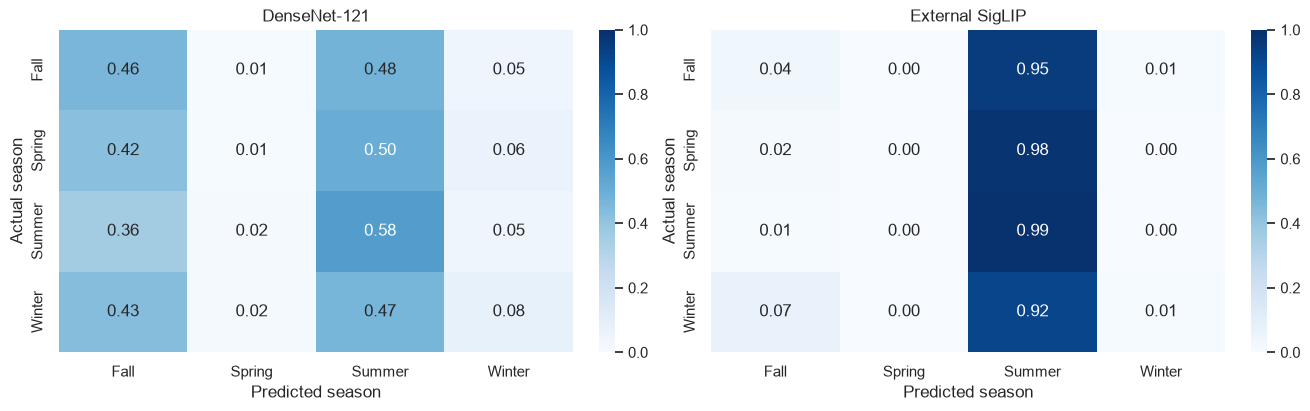

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,DenseNet-121,0.282,0.2176,0.282,0.2176,0.508
1,External SigLIP,0.260,0.1239,0.260,0.1239,0.488
2,External SigLIP minus selected model,-0.022,-0.0938,-0.022,-0.0938,-0.020


,Model,Season,Support,Precision,Recall,F1
0,DenseNet-121,Fall,125,0.2762,0.464,0.3463
1,DenseNet-121,Spring,125,0.1667,0.008,0.0153
2,DenseNet-121,Summer,125,0.2835,0.576,0.3799
3,DenseNet-121,Winter,125,0.3333,0.080,0.1290
4,External SigLIP,Fall,125,0.2941,0.040,0.0704
5,External SigLIP,Spring,125,0.0000,0.000,0.0000
6,External SigLIP,Summer,125,0.2578,0.992,0.4092
7,External SigLIP,Winter,125,0.5000,0.008,0.0157


,Model,Predicted season,Images,Share %
0,DenseNet-121,Fall,210,42.0
1,DenseNet-121,Spring,6,1.2
2,DenseNet-121,Summer,254,50.8
3,DenseNet-121,Winter,30,6.0
4,External SigLIP,Fall,17,3.4
5,External SigLIP,Spring,0,0.0
6,External SigLIP,Summer,481,96.2
7,External SigLIP,Winter,2,0.4


,Images,Share %
paired_outcome,,
Both correct,75,15.0
Selected only correct,66,13.2
SOTA only correct,55,11.0
Both wrong,304,60.8


Prediction agreement: 51.0%
Saved comparison: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/external_model_comparison.csv
Saved per-class results: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/external_per_class_comparison.csv
Saved prediction distribution: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/external_prediction_distribution.csv
Saved paired predictions: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/paired_external_predictions.csv
Saved score matrices: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/external_evaluation_scores.npz
Saved confusion matrices: /Users/s4030327/Machine-Learning-Assignment-2/outputs/task2/independent_evaluation/external_confusion_matrices.png


In [4]:
def as_probabilities(scores):
    scores = np.asarray(scores, dtype=np.float64)
    row_sums = scores.sum(axis=1, keepdims=True)
    if np.all(scores >= 0) and np.allclose(row_sums, 1.0, atol=1e-4):
        return scores / np.clip(row_sums, 1e-12, None)
    shifted = scores - scores.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)

selected_probabilities = as_probabilities(selected_scores)
sota_probabilities = as_probabilities(sota_scores)
selected_predictions = selected_probabilities.argmax(axis=1)
sota_predictions = sota_probabilities.argmax(axis=1)

selected_name = str(selected_package['selected_model'])
comparison = pd.DataFrame([
    evaluate_predictions(
        Y_EXTERNAL, selected_predictions, selected_probabilities, selected_name
    ),
    evaluate_predictions(
        Y_EXTERNAL, sota_predictions, sota_probabilities, 'External SigLIP'
    ),
])
metric_columns = [
    'Top-1 accuracy', 'Macro-F1', 'Balanced accuracy',
    'Weighted F1', 'Top-2 accuracy',
]
difference = {'Model': 'External SigLIP minus selected model'}
for metric in metric_columns:
    difference[metric] = comparison.loc[1, metric] - comparison.loc[0, metric]
comparison_with_difference = pd.concat(
    [comparison, pd.DataFrame([difference])], ignore_index=True
)

selected_per_class = per_class_table(
    Y_EXTERNAL, selected_predictions, CLASSES
)
selected_per_class.insert(0, 'Model', selected_name)
sota_per_class = per_class_table(Y_EXTERNAL, sota_predictions, CLASSES)
sota_per_class.insert(0, 'Model', 'External SigLIP')
per_class_results = pd.concat(
    [selected_per_class, sota_per_class], ignore_index=True
)

prediction_distribution = pd.concat([
    pd.DataFrame({
        'Model': model_name,
        'Predicted season': CLASSES,
        'Images': np.bincount(predictions, minlength=len(CLASSES)),
    })
    for model_name, predictions in [
        (selected_name, selected_predictions),
        ('External SigLIP', sota_predictions),
    ]
], ignore_index=True)
prediction_distribution['Share %'] = (
    prediction_distribution['Images'] / len(Y_EXTERNAL) * 100
)
selected_correct = selected_predictions == Y_EXTERNAL
sota_correct = sota_predictions == Y_EXTERNAL
paired_category = np.select(
    [
        selected_correct & sota_correct,
        selected_correct & ~sota_correct,
        ~selected_correct & sota_correct,
    ],
    ['Both correct', 'Selected only correct', 'SOTA only correct'],
    default='Both wrong',
)
paired_results = pd.DataFrame({
    'id': EXTERNAL_IDS,
    'articleType': external_frame['articleType'].to_numpy(),
    'actual': [CLASSES[index] for index in Y_EXTERNAL],
    'selected_prediction': [CLASSES[index] for index in selected_predictions],
    'sota_prediction': [CLASSES[index] for index in sota_predictions],
    'selected_correct': selected_correct,
    'sota_correct': sota_correct,
    'paired_outcome': paired_category,
    'models_agree': selected_predictions == sota_predictions,
    'selected_confidence': selected_probabilities.max(axis=1),
    'sota_confidence': sota_probabilities.max(axis=1),
})
paired_summary = (
    paired_results['paired_outcome']
    .value_counts()
    .reindex(
        ['Both correct', 'Selected only correct', 'SOTA only correct', 'Both wrong'],
        fill_value=0,
    )
    .rename('Images')
    .to_frame()
)
paired_summary['Share %'] = paired_summary['Images'] / len(paired_results) * 100

actual_labels = [CLASSES[index] for index in Y_EXTERNAL]
represented_labels = [CLASSES[index] for index in REPRESENTED_INDICES]
figure, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for axis, predictions, title in [
    (axes[0], selected_predictions, selected_name),
    (axes[1], sota_predictions, 'External SigLIP'),
]:
    predicted_labels = [CLASSES[index] for index in predictions]
    matrix = pd.crosstab(
        pd.Categorical(actual_labels, categories=represented_labels),
        pd.Categorical(predicted_labels, categories=CLASSES),
        normalize='index', dropna=False,
    )
    sns.heatmap(
        matrix, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel('Predicted season')
    axis.set_ylabel('Actual season')
figure_path = EVALUATION_DIR / 'external_confusion_matrices.png'
figure.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()

comparison_path = EVALUATION_DIR / 'external_model_comparison.csv'
per_class_path = EVALUATION_DIR / 'external_per_class_comparison.csv'
distribution_path = EVALUATION_DIR / 'external_prediction_distribution.csv'
paired_path = EVALUATION_DIR / 'paired_external_predictions.csv'
score_path = EVALUATION_DIR / 'external_evaluation_scores.npz'
comparison_with_difference.to_csv(comparison_path, index=False)
per_class_results.to_csv(per_class_path, index=False)
prediction_distribution.to_csv(distribution_path, index=False)
paired_results.to_csv(paired_path, index=False)
np.savez_compressed(
    score_path,
    source_dataset=np.asarray('fnauman/fashion-second-hand-front-only-rgb'),
    sota_model_id=np.asarray(SOTA_MODEL_ID),
    sota_revision=np.asarray(SOTA_REVISION),
    selected_model=np.asarray(selected_name),
    task2_fingerprint=np.asarray(RUN_FINGERPRINT),
    classes=np.asarray(CLASSES),
    external_ids=EXTERNAL_IDS,
    true_indices=Y_EXTERNAL,
    selected_scores=selected_scores,
    sota_scores=sota_scores,
)

display(comparison_with_difference.round(4))
display(per_class_results.round(4))
display(prediction_distribution.round(2))
display(paired_summary.round(2))
print('Prediction agreement:', f'{paired_results["models_agree"].mean():.1%}')
print('Saved comparison:', comparison_path)
print('Saved per-class results:', per_class_path)
print('Saved prediction distribution:', distribution_path)
print('Saved paired predictions:', paired_path)
print('Saved score matrices:', score_path)
print('Saved confusion matrices:', figure_path)

## Independent-evaluation interpretation

DenseNet-121 leads on this matched external set: its accuracy and balanced accuracy are 0.2820 and its macro-F1 is 0.2176, compared with 0.2600 and 0.1239 for SigLIP. The macro-F1 margin is 0.0938. Because every season has exactly 125 images, accuracy and balanced accuracy coincide. DenseNet has the higher F1 for Fall (0.3463 versus 0.0704), Spring (0.0153 versus 0), and Winter (0.1290 versus 0.0157); Summer is the sole exception, where SigLIP leads 0.4092 to 0.3799. Thus, the overall conclusion favours DenseNet, but not every class-wise F1 supports it.

The paired comparison shows complementary errors: DenseNet alone is correct on 66 images, SigLIP alone on 55, both are correct on 75, and both fail on 304. Their predictions agree on 51.0% of images. DenseNet still strongly underpredicts Spring (6 predictions) and Winter (30), but its distribution is less collapsed than SigLIP's: DenseNet predicts Fall/Spring/Summer/Winter 210/6/254/30 times, whereas SigLIP predicts them 17/0/481/2 times. SigLIP assigns 96.2% of all images to Summer and recalls 99.2% of Summer at the cost of zero Spring recall and 0.8% Winter recall. DenseNet's largest confusion is also toward Summer, but its Fall predictions are much more frequent and useful.

Article-type matching changes the interpretation of the failure. Each of the 12 types has exactly the same count in every season, so differences cannot be explained by one season containing more jackets, dresses, or trousers than another. DenseNet exceeds SigLIP most on Blazer (41.7% versus 25.0%), Dress (36.1% versus 25.0%), and Trousers (33.8% versus 25.0%); SigLIP is modestly better on Outerwear, Jacket, and Top. Several types have very small totals, so these type-specific differences are descriptive rather than stable estimates.

Both models nevertheless transfer poorly compared with their internal validation evidence. The remaining explanation is substantial domain and label shift: these are second-hand garment photographs with different resolution, framing, backgrounds, and merchandising context, while season is not always directly visible from the garment alone. The matched sample removes the earlier article-type-composition confound but cannot remove those shifts. This external result therefore diagnoses limited transfer and does not retrospectively change Notebook 05's frozen-validation selection. The model-card figures are not directly comparable, and overlap between SigLIP's undocumented training data and the RISE source cannot be ruled out.